# IDS anomaly detection: train, validate, explain

фиксированные train/validation/test splits, fit Isolation Forest только на normal training rows, выбор threshold только на validation, финальная оценка на test и SHAP-анализ.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)
import shap
from scipy.stats import ks_2samp
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

from ids_ml_lab.features import FEATURES
from ids_ml_lab.modeling import (
    anomaly_scores,
    classification_metrics,
    make_pipeline,
    select_threshold,
)
from ids_ml_lab.training import bootstrap_ci, cross_validate, train

SEED = 42
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA = ROOT / "data/prepared"
ARTIFACT = ROOT / "models/ids_iforest_v1"
sns.set_theme(style="whitegrid")

## 1. Фиксированный train/validation/test split

Splits подготовлены reproducible builder-ом с seed 42 и stratification. Мы не делаем новый случайный split в notebook: так test set остаётся стабильным и не попадает в выбор threshold.

In [2]:
manifest = json.loads((DATA / "dataset_info.json").read_text())
train_df = pd.read_parquet(DATA / "train.parquet")
validation_df = pd.read_parquet(DATA / "validation.parquet")
test_df = pd.read_parquet(DATA / "test.parquet")
assert all(
    set(FEATURES + ["label", "attack_type"]) == set(frame.columns)
    for frame in [train_df, validation_df, test_df]
)
pd.DataFrame(
    {
        name: frame["label"].value_counts().sort_index()
        for name, frame in {"train": train_df, "validation": validation_df, "test": test_df}.items()
    }
).T

label,0,1
train,7200,7200
validation,2400,2400
test,2400,2400


## 2. Preprocessing и Isolation Forest

Pipeline применяет OneHotEncoder к protocol/service/flag и RobustScaler к числовым полям. `handle_unknown=ignore` обязателен для live traffic. Модель обучается только на normal training rows; labels не используются при fit.

In [3]:
pipeline = make_pipeline(SEED)
normal_train = train_df.loc[train_df.label == 0, FEATURES]
pipeline.fit(normal_train)
validation_y = validation_df.label.to_numpy()
test_y = test_df.label.to_numpy()
validation_scores = anomaly_scores(pipeline, validation_df[FEATURES])
test_scores = anomaly_scores(pipeline, test_df[FEATURES])
len(normal_train), validation_scores.shape, test_scores.shape

(7200, (4800,), (4800,))

## 3. ROC AUC и PR AUC

Для anomaly score большее значение означает более аномальное событие. PR AUC особенно важен при несбалансированных классах.

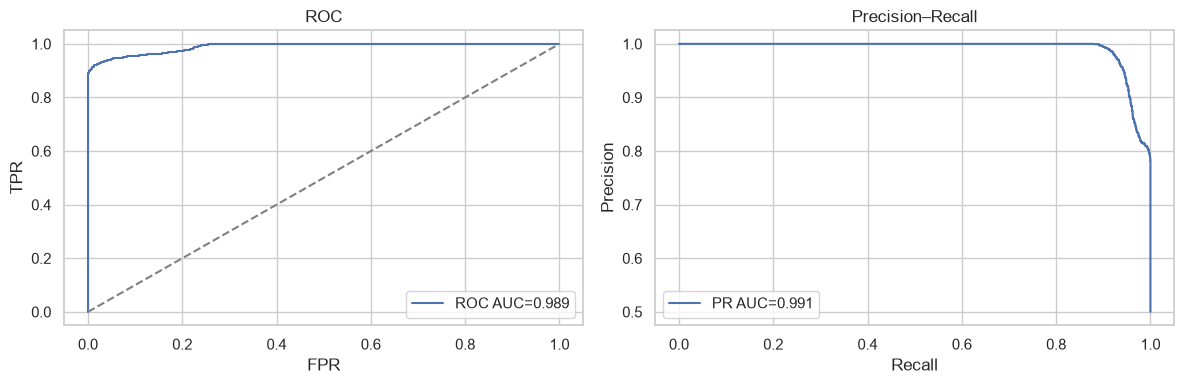

In [4]:
roc_auc = roc_auc_score(test_y, test_scores)
pr_auc = average_precision_score(test_y, test_scores)
fpr_curve, tpr_curve, _ = roc_curve(test_y, test_scores)
precision_curve, recall_curve, _ = precision_recall_curve(test_y, test_scores)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr_curve, tpr_curve, label=f"ROC AUC={roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="grey")
axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC")
axes[0].legend()
axes[1].plot(recall_curve, precision_curve, label=f"PR AUC={pr_auc:.3f}")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision–Recall")
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Threshold selection на validation

Выбираем максимум F1 среди thresholds с validation FPR ≤ 5%. Test labels здесь не используются.

In [5]:
threshold = select_threshold(validation_y, validation_scores, max_fpr=0.05)
validation_metrics = classification_metrics(validation_y, validation_scores, threshold)
test_metrics = classification_metrics(test_y, test_scores, threshold)
pd.DataFrame([validation_metrics | {"split": "validation"}, test_metrics | {"split": "test"}]).drop(
    columns="confusion_matrix"
).set_index("split").T

split,validation,test
roc_auc,0.990512,0.989355
pr_auc,0.991673,0.990719
accuracy,0.955417,0.951458
balanced_accuracy,0.955417,0.951458
precision,0.972751,0.972938
recall,0.937083,0.928750
f1,0.954584,0.950330
specificity,0.973750,0.974167
false_positive_rate,0.026250,0.025833
matthews_corrcoef,0.911446,0.903849


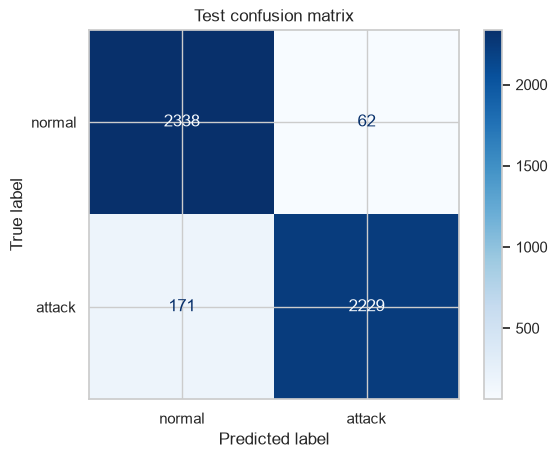

In [6]:
test_predictions = (test_scores >= threshold).astype(int)
ConfusionMatrixDisplay.from_predictions(
    test_y, test_predictions, display_labels=["normal", "attack"], cmap="Blues"
)
plt.title("Test confusion matrix")
plt.show()

## 5. Cross-validation и bootstrap confidence intervals

В каждом fold модель заново fit-ится только на normal-части training fold. Bootstrap CI считается на неизменном test score.

In [7]:
cv_report = cross_validate(train_df, folds=5, seed=SEED)
bootstrap_report = {
    "roc_auc": bootstrap_ci(test_y, test_scores, roc_auc_score, iterations=500, seed=SEED),
    "pr_auc": bootstrap_ci(
        test_y, test_scores, average_precision_score, iterations=500, seed=SEED + 1
    ),
}
cv_report, bootstrap_report

({'folds': [{'fold': 1,
    'roc_auc': 0.9906095679012346,
    'pr_auc': 0.9918314963184844},
   {'fold': 2, 'roc_auc': 0.9891415895061728, 'pr_auc': 0.9904769856355871},
   {'fold': 3, 'roc_auc': 0.9910199652777777, 'pr_auc': 0.9923119190315393},
   {'fold': 4, 'roc_auc': 0.9903737461419753, 'pr_auc': 0.9914098457389624},
   {'fold': 5, 'roc_auc': 0.9896383101851852, 'pr_auc': 0.9910003710712482}],
  'roc_auc_mean': 0.9901566358024692,
  'roc_auc_std': 0.0007577272922540626,
  'pr_auc_mean': 0.9914061235591642,
  'pr_auc_std': 0.0007122769193313462},
 {'roc_auc': {'estimate': 0.9893550347222224,
   'low': 0.9875084286198333,
   'high': 0.9911572585125002},
  'pr_auc': {'estimate': 0.9907186761950526,
   'low': 0.9890934833589402,
   'high': 0.9922923607882089}})

## 6. KS separation

Two-sample KS сравнивает distributions anomaly score для normal и attack. Большой statistic означает более сильное разделение, но сам по себе не заменяет operational metrics.

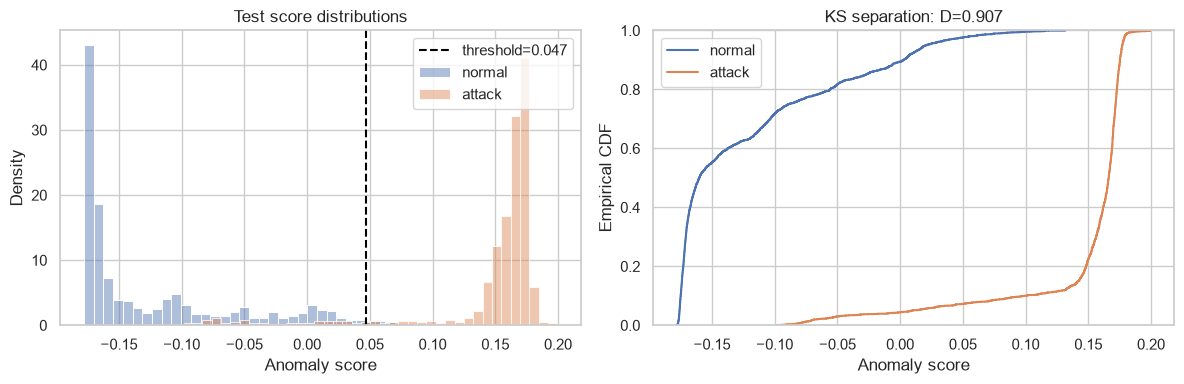

{'ks_statistic': np.float64(0.9066666666666667), 'pvalue': np.float64(0.0)}

In [8]:
normal_scores = test_scores[test_y == 0]
attack_scores = test_scores[test_y == 1]
ks = ks_2samp(normal_scores, attack_scores)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(normal_scores, bins=40, stat="density", alpha=0.45, label="normal", ax=axes[0])
sns.histplot(attack_scores, bins=40, stat="density", alpha=0.45, label="attack", ax=axes[0])
axes[0].axvline(threshold, color="black", linestyle="--", label=f"threshold={threshold:.3f}")
axes[0].set(xlabel="Anomaly score", title="Test score distributions")
axes[0].legend()
sns.ecdfplot(normal_scores, label="normal", ax=axes[1])
sns.ecdfplot(attack_scores, label="attack", ax=axes[1])
axes[1].set(xlabel="Anomaly score", ylabel="Empirical CDF", title=f"KS separation: D={ks.statistic:.3f}")
axes[1].legend()
plt.tight_layout()
plt.show()
{"ks_statistic": ks.statistic, "pvalue": ks.pvalue}

## 7. SHAP-анализ

TreeExplainer работает на transformed features. Global mean |SHAP| показывает, какие transformed признаки сильнее влияют на raw Isolation Forest output; знак не следует интерпретировать как причинность.

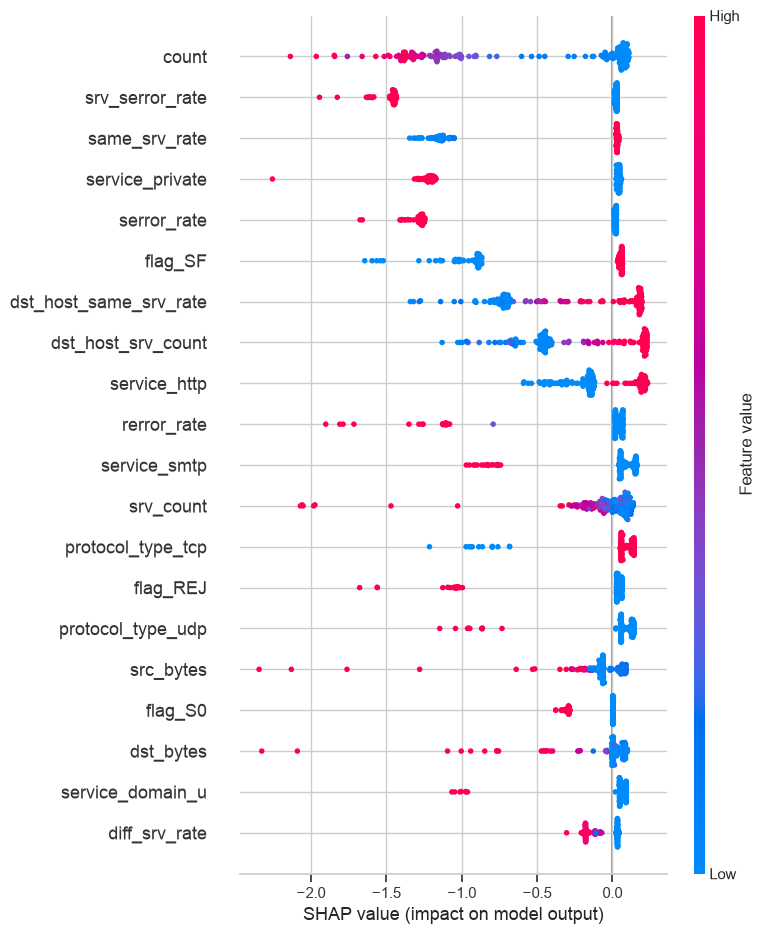

In [9]:
preprocessor = pipeline.named_steps["preprocessor"]
forest = pipeline.named_steps["model"]
explain_rows = validation_df[FEATURES].sample(n=min(200, len(validation_df)), random_state=SEED)
X_explain = preprocessor.transform(explain_rows)
transformed_names = preprocessor.get_feature_names_out()
explainer = shap.TreeExplainer(forest)
shap_values = explainer(X_explain, check_additivity=False)
shap.summary_plot(
    shap_values.values, X_explain, feature_names=transformed_names, show=False, max_display=20
)
plt.tight_layout()
plt.show()

In [10]:
shap_importance = pd.DataFrame(
    {"feature": transformed_names, "mean_abs_shap": np.abs(shap_values.values).mean(axis=0)}
).sort_values("mean_abs_shap", ascending=False)
shap_importance.head(20)

,feature,mean_abs_shap
33,count,0.619896
36,srv_serror_rate,0.555437
38,same_srv_rate,0.513490
16,service_private,0.482845
35,serror_rate,0.478046
29,flag_SF,0.477943
42,dst_host_same_srv_rate,0.471496
41,dst_host_srv_count,0.381149
12,service_http,0.206717
37,rerror_rate,0.166046


## 8. Export artifact

Для экспорта вызываем тот же канонический training path, что и CLI `uv run ids-train`. Он создаёт согласованный полный artifact, включая validation report, metadata и SHAP importance.

In [11]:
export_report = train(DATA, ARTIFACT, seed=SEED)
expected_files = {
    "model.joblib",
    "features.json",
    "threshold.json",
    "metadata.json",
    "validation_report.json",
    "shap_importance.csv",
}
assert expected_files == {path.name for path in ARTIFACT.iterdir() if path.is_file()}
assert export_report["test"] == test_metrics
ARTIFACT

PosixPath('/Users/newuser/Documents/OTUS/2409/ids-ml-detection-lab/models/ids_iforest_v1')